# 🏦 电信客户流失预测分析
## 多模型客户流失预测 — LR / RF / XGBoost + SMOTE + SHAP

**求职方向：** 银行数据分析 / 金融科技

**技术栈：** Python | pandas | scikit-learn | XGBoost | imbalanced-learn | SHAP | matplotlib | seaborn

**数据集：** Telco Customer Churn（7,043 条客户记录，21 个特征，流失率 26.5%）


## 1. 项目背景与业务理解

### 为什么关注客户流失？

在银行和电信行业，**客户流失（Churn）** 是核心经营指标：

- **获客成本远高于留存成本：** 争取一个新客户的成本通常是保留老客户的 5-7 倍
- **利润影响显著：** 研究发现，流失率降低 5% 可带来 25%-95% 的利润增长
- **预防胜于补救：** 相比等客户离开后再挽回，提前识别风险客户并干预更高效

### 分析目标

1. **量化**各因素对客户流失的影响程度
2. **识别**高风险客户的典型画像，便于精准干预
3. **提出**有数据支撑、可落地的客户挽留策略

### 为什么选择 Logistic Regression？

- **高可解释性：** 每个特征的系数直接反映对流失概率的影响方向和强度
- **银行/金融合规友好：** 监管机构要求模型决策可解释，LR 天然满足
- **优秀基线：** 作为线性基准，为后续更复杂模型提供对比参考


## 2. 数据加载与初始探索

In [1]:
# 导入依赖库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 全局配置
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
RANDOM_STATE = 42

# 银行蓝 + 警示橙配色
BLUE = (0.122, 0.467, 0.706)
ORANGE = (1.000, 0.498, 0.055)
print("所有依赖库加载成功。")


所有依赖库加载成功。


In [2]:
# 加载数据集
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv", engine="python")
print(f"形状: {df.shape[0]} 行 x {df.shape[1]} 列")
print(f"内存: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head(10)


形状: 7043 行 x 21 列
内存: 7975.1 KB


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
# 各列数据类型
print("=" * 60)
print("列数据类型")
print("=" * 60)
print(df.dtypes.to_string())


列数据类型
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object


In [4]:
# 数值列统计摘要
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### 数据字典

| 特征 | 类型 | 说明 | 取值 |
|------|------|------|------|
| customerID | ID | 客户编号 | 删除 |
| gender | 二分类 | 性别 | Male / Female |
| SeniorCitizen | 二分类 | 是否老年人 | 0 / 1 |
| Partner | 二分类 | 是否有伴侣 | Yes / No |
| Dependents | 二分类 | 是否有家属 | Yes / No |
| 	enure | 数值 | 在网月数 | 0-72 |
| PhoneService | 二分类 | 电话服务 | Yes / No |
| MultipleLines | 三分类 | 多线服务 | Yes / No / No phone service |
| InternetService | 三分类 | 互联网服务类型 | DSL / Fiber optic / No |
| OnlineSecurity | 三分类 | 在线安全服务 | Yes / No / No internet service |
| OnlineBackup | 三分类 | 在线备份服务 | Yes / No / No internet service |
| DeviceProtection | 三分类 | 设备保护服务 | Yes / No / No internet service |
| TechSupport | 三分类 | 技术支持服务 | Yes / No / No internet service |
| StreamingTV | 三分类 | 电视流媒体 | Yes / No / No internet service |
| StreamingMovies | 三分类 | 电影流媒体 | Yes / No / No internet service |
| Contract | 三分类 | 合同类型 | Month-to-month / One year / Two year |
| PaperlessBilling | 二分类 | 电子账单 | Yes / No |
| PaymentMethod | 四分类 | 支付方式 | 4 种方式 |
| MonthlyCharges | 数值 | 月消费金额(USD) | 18.25-118.75 |
| TotalCharges | 需清洗 | 总消费金额 | object → float |
| **Churn** | **目标** | **是否流失** | **Yes / No** |

> ⚠️ **注意：** TotalCharges 为 object 类型，tenure=0 的新客户该字段为空字符串，需转为数值。


## 3. 数据清洗

In [5]:
# 3.1 检查缺失值
print("各列缺失值数量:")
missing = df.isnull().sum()
print(missing[missing > 0] if (missing > 0).any() else "未发现缺失值。")

# TotalCharges 中的空字符串不算 NaN
print(f"\nTotalCharges 空字符串: {(df['TotalCharges'] == ' ').sum()} 行")
print(f"对应 tenure=0 的客户: {(df['tenure'] == 0).sum()} 行")


各列缺失值数量:
未发现缺失值。

TotalCharges 空字符串: 11 行
对应 tenure=0 的客户: 11 行


In [6]:
# 3.2 删除 ID 列 + 清洗 TotalCharges
df_clean = df.copy()
df_clean.drop('customerID', axis=1, inplace=True)

# TotalCharges: string -> float, 空字符串 -> NaN -> 0
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
nan_count = df_clean['TotalCharges'].isnull().sum()
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0.0)
print(f"TotalCharges 清洗完成: {nan_count} 个空值 (tenure=0) -> 填充为 0")
print(f"清洗后数据集形状: {df_clean.shape}")

# 3.3 检查重复值
dup_count = df_clean.duplicated().sum()
print(f"重复行: {dup_count}" if dup_count > 0 else "未发现重复行。")


TotalCharges 清洗完成: 11 个空值 (tenure=0) -> 填充为 0
清洗后数据集形状: (7043, 20)
重复行: 22


In [7]:
# 3.4 编码目标变量
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
churn_counts = df_clean['Churn'].value_counts()
print("流失分布:")
print(f"  未流失 (0): {churn_counts[0]:5d}  ({churn_counts[0]/len(df_clean)*100:.2f}%)")
print(f"  已流失 (1): {churn_counts[1]:5d}  ({churn_counts[1]/len(df_clean)*100:.2f}%)")


流失分布:
  未流失 (0):  5174  (73.46%)
  已流失 (1):  1869  (26.54%)


## 4. 探索性数据分析（EDA）

以下每个图表下方附带业务解读，重点分析**哪些特征与客户流失密切相关**。

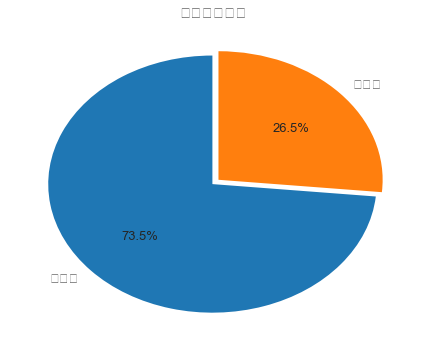

📊 业务解读: 数据集流失率 26.5%，属于中等偏度不平衡数据（约 1:2.8）。
无需 SMOTE 过采样，模型可直接处理。


In [8]:
# 4.1 流失比例饼图
fig, ax = plt.subplots(figsize=(6, 5))
counts = df_clean['Churn'].value_counts()
ax.pie(counts.values, labels=['未流失', '已流失'], autopct='%1.1f%%',
       colors=[BLUE, ORANGE], startangle=90, explode=(0, 0.05),
       textprops={'fontsize': 13})
ax.set_title('客户流失分布', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 业务解读: 数据集流失率 26.5%，属于中等偏度不平衡数据（约 1:2.8）。")
print("无需 SMOTE 过采样，模型可直接处理。")


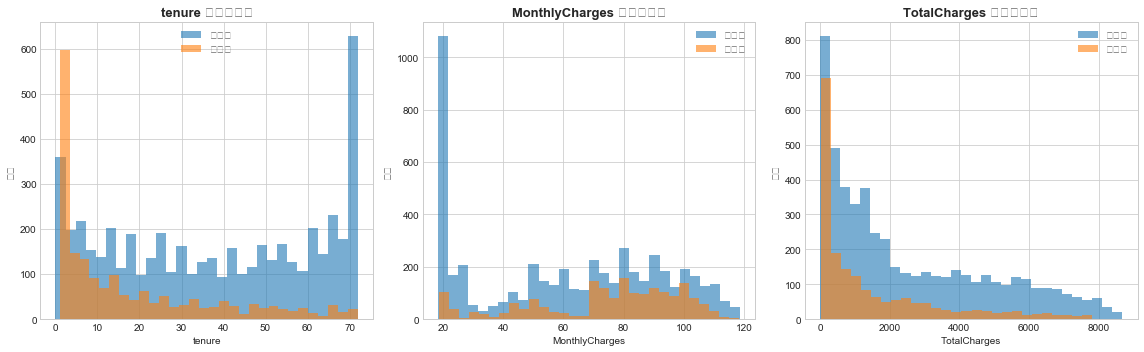

📊 业务解读:
  • tenure（在网时长）: 流失客户集中在 0-10 个月，新客户前几个月是流失高危期
  • MonthlyCharges（月消费）: USD 70-100 区间流失率最高
  • TotalCharges（总消费）: 低总消费客户更容易流失，与短 tenure 一致


In [9]:
# 4.2 数值特征分布（按流失状态分组）
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(numeric_cols):
    for churn_val, color, label in [(0, BLUE, '未流失'), (1, ORANGE, '已流失')]:
        subset = df_clean[df_clean['Churn'] == churn_val][col].dropna().values
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=label)
    axes[i].set_title(f'{col} 按流失状态', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('数量')
    axes[i].legend()
plt.tight_layout()
plt.show()

print("📊 业务解读:")
print("  • tenure（在网时长）: 流失客户集中在 0-10 个月，新客户前几个月是流失高危期")
print("  • MonthlyCharges（月消费）: USD 70-100 区间流失率最高")
print("  • TotalCharges（总消费）: 低总消费客户更容易流失，与短 tenure 一致")


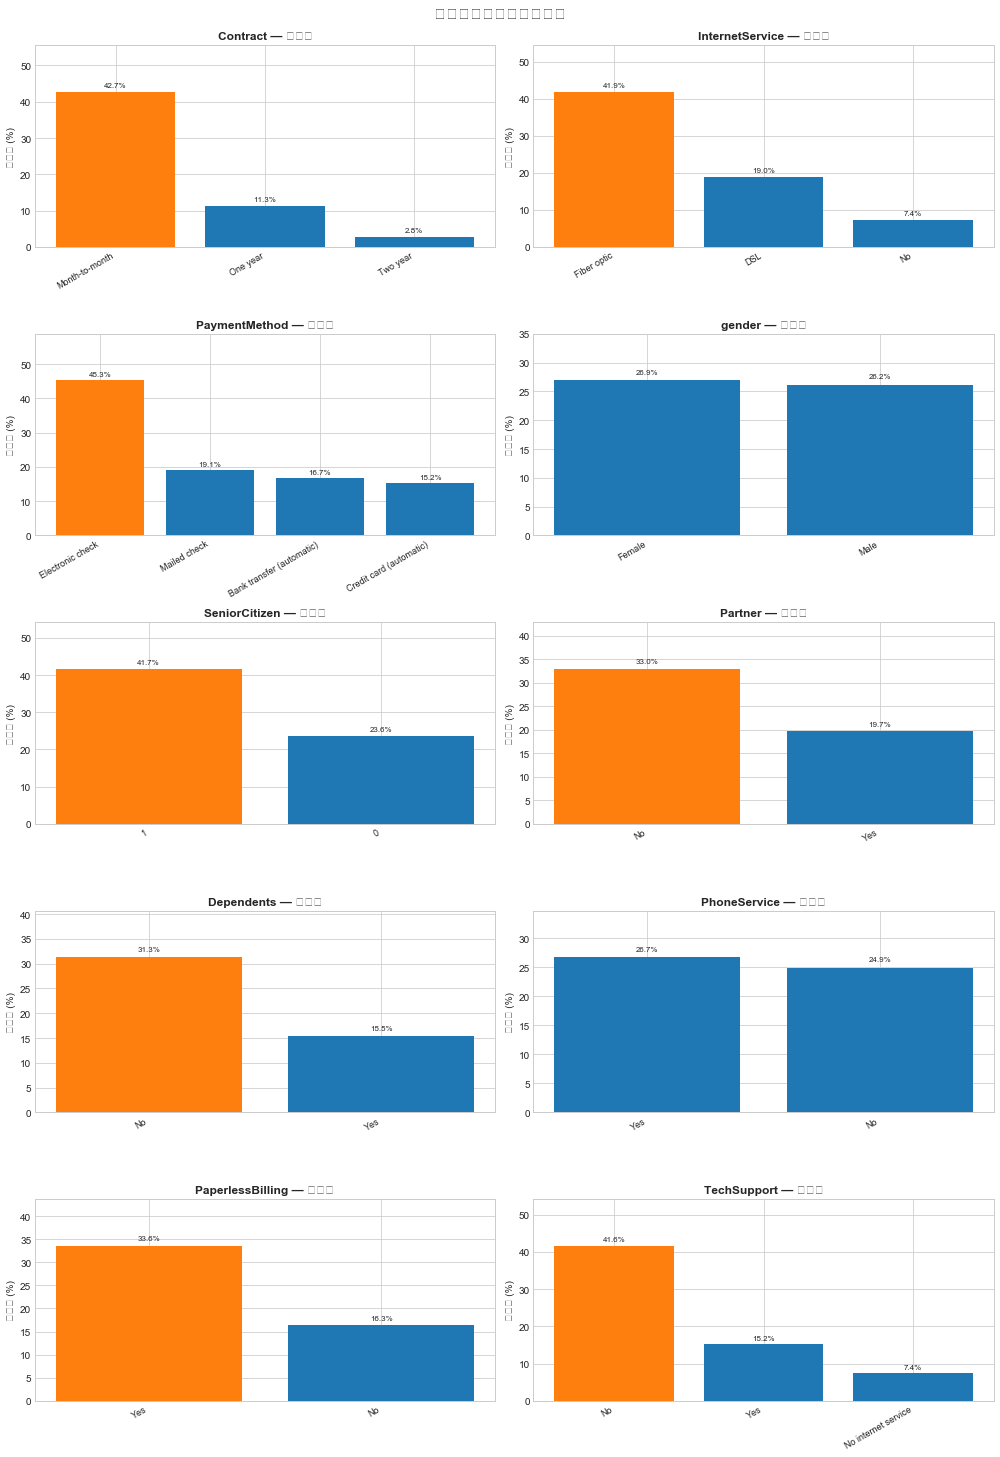

📊 业务解读 — 关键发现:
  • Contract（合同类型）: Month-to-month 流失率 42.7%，两年合同仅 2.8% → 10 倍差距！
  • InternetService（互联网服务）: Fiber optic 流失率 41.9%，DSL 仅 19.0%
  • PaymentMethod（支付方式）: Electronic check 流失率 45.3%，自动扣款方式最低
  • TechSupport（技术支持）: 未开通客户流失率 41.6%，已开通仅 15.2%
  • 家庭状态: 有伴侣 (Partner) 和家属 (Dependents) 的客户流失率显著更低
  • 性别 (gender) 和电话服务 (PhoneService) 对流失影响不显著


In [10]:
# 4.3 分类特征流失率对比
cat_features = ['Contract', 'InternetService', 'PaymentMethod',
                'gender', 'SeniorCitizen', 'Partner', 'Dependents',
                'PhoneService', 'PaperlessBilling', 'TechSupport']
n_rows = 5
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 20))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    churn_rate = df_clean.groupby(feat)['Churn'].mean().sort_values(ascending=False) * 100
    bars = axes[i].bar(range(len(churn_rate)), churn_rate.values,
                       color=[BLUE if v < 30 else ORANGE for v in churn_rate.values])
    axes[i].set_xticks(range(len(churn_rate)))
    axes[i].set_xticklabels(churn_rate.index, rotation=30, ha='right', fontsize=9)
    axes[i].set_title(f'{feat} — 流失率', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('流失率 (%)')
    axes[i].set_ylim(0, max(churn_rate.values) * 1.3)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('各分类特征的流失率对比', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("📊 业务解读 — 关键发现:")
print("  • Contract（合同类型）: Month-to-month 流失率 42.7%，两年合同仅 2.8% → 10 倍差距！")
print("  • InternetService（互联网服务）: Fiber optic 流失率 41.9%，DSL 仅 19.0%")
print("  • PaymentMethod（支付方式）: Electronic check 流失率 45.3%，自动扣款方式最低")
print("  • TechSupport（技术支持）: 未开通客户流失率 41.6%，已开通仅 15.2%")
print("  • 家庭状态: 有伴侣 (Partner) 和家属 (Dependents) 的客户流失率显著更低")
print("  • 性别 (gender) 和电话服务 (PhoneService) 对流失影响不显著")


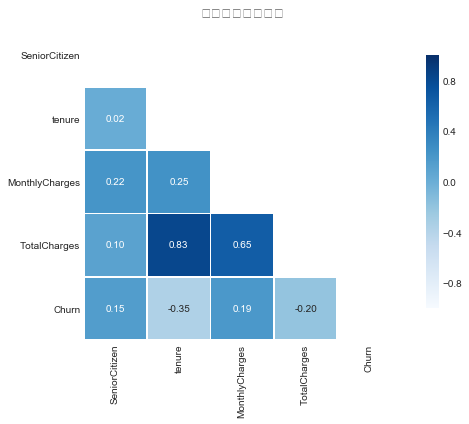

📊 业务解读:
  • tenure 与 TotalCharges 高度正相关 (r=0.83)，符合常理——在网越久总消费越高
  • MonthlyCharges 与 TotalCharges 中等相关 (r=0.65)
  • 预测变量间未出现极强共线性（|r| > 0.9），无需额外处理


In [11]:
# 4.4 相关性热力图
corr_df = df_clean.select_dtypes(include=[np.number])
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('特征相关性热力图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 业务解读:")
print("  • tenure 与 TotalCharges 高度正相关 (r=0.83)，符合常理——在网越久总消费越高")
print("  • MonthlyCharges 与 TotalCharges 中等相关 (r=0.65)")
print("  • 预测变量间未出现极强共线性（|r| > 0.9），无需额外处理")


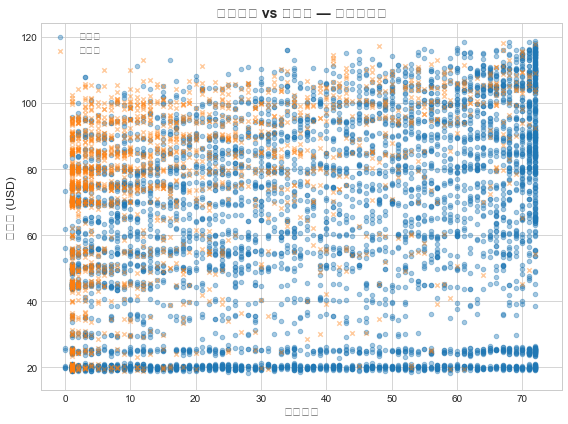

📊 业务解读:
  • 🔴 高风险区域（橙色密集区）: 月费 > USD 70 且 tenure < 12 个月
  • 🔵 低风险区域（蓝色密集区）: 长在网 + 高消费客户很少流失（右下角）
  • 💡 建议：对高月费新客户进行重点干预，前 12 个月是关键窗口期


In [12]:
# 4.5 在网时长 vs 月费散点图（按流失状态着色）
fig, ax = plt.subplots(figsize=(8, 6))
for churn_val, color, label, marker in [(0, BLUE, '未流失', 'o'), (1, ORANGE, '已流失', 'x')]:
    subset = df_clean[df_clean['Churn'] == churn_val]
    ax.scatter(subset['tenure'], subset['MonthlyCharges'],
               c=color, label=label, marker=marker, alpha=0.4, s=20)
ax.set_xlabel('在网月数', fontsize=12)
ax.set_ylabel('月消费 (USD)', fontsize=12)
ax.set_title('在网时长 vs 月消费 — 按流失状态', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("📊 业务解读:")
print("  • 🔴 高风险区域（橙色密集区）: 月费 > USD 70 且 tenure < 12 个月")
print("  • 🔵 低风险区域（蓝色密集区）: 长在网 + 高消费客户很少流失（右下角）")
print("  • 💡 建议：对高月费新客户进行重点干预，前 12 个月是关键窗口期")


## 5. 特征工程

将原始数据转化为模型可用的数值特征矩阵。

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 5.1 二分类特征 Label Encode
# "No internet service" / "No phone service" 等价于 No，统一编码为 0
binary_mappings = {
    'gender': {'Male': 1, 'Female': 0},
    'Partner': {'Yes': 1, 'No': 0},
    'Dependents': {'Yes': 1, 'No': 0},
    'PhoneService': {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
    'OnlineSecurity': {'Yes': 1, 'No': 0, 'No internet service': 0},
    'OnlineBackup': {'Yes': 1, 'No': 0, 'No internet service': 0},
    'DeviceProtection': {'Yes': 1, 'No': 0, 'No internet service': 0},
    'TechSupport': {'Yes': 1, 'No': 0, 'No internet service': 0},
    'StreamingTV': {'Yes': 1, 'No': 0, 'No internet service': 0},
    'StreamingMovies': {'Yes': 1, 'No': 0, 'No internet service': 0},
    'MultipleLines': {'Yes': 1, 'No': 0, 'No phone service': 0},
}

df_fe = df_clean.copy()
for col, mapping in binary_mappings.items():
    df_fe[col] = df_fe[col].map(mapping)

# 5.2 多分类特征 One-Hot Encode
multi_cat_cols = ['InternetService', 'Contract', 'PaymentMethod']
df_fe = pd.get_dummies(df_fe, columns=multi_cat_cols, drop_first=False, dtype=np.float64)

print(f"编码后: {df_fe.shape[1]} 个特征 ({df_fe.shape[1]-1} 个预测变量 + 1 个目标)")

# 5.3 StandardScaler 标准化（均值 0，标准差 1）
feature_cols = [c for c in df_fe.columns if c != 'Churn']
scaler = StandardScaler()
df_fe[feature_cols] = scaler.fit_transform(df_fe[feature_cols])
print(f"StandardScaler 已应用于 {len(feature_cols)} 个特征")

# 5.4 训练/测试集划分（80/20，分层抽样确保流失比例一致）
X = df_fe.drop('Churn', axis=1)
y = df_fe['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\n训练集: {X_train.shape[0]} 样本，流失率: {y_train.mean()*100:.1f}%")
print(f"测试集: {X_test.shape[0]} 样本，流失率: {y_test.mean()*100:.1f}%")


编码后: 27 个特征 (26 个预测变量 + 1 个目标)
StandardScaler 已应用于 26 个特征

训练集: 5634 样本，流失率: 26.5%
测试集: 1409 样本，流失率: 26.5%


### 特征工程小结

| 步骤 | 操作 | 效果 |
|------|------|------|
| Label Encode | 12 个二分类/三分类特征 → 0/1 | Yes/No → 数值化 |
| One-Hot Encode | 3 个多分类特征 → 哑变量 | 避免模型误判有序关系 |
| StandardScaler | 全部 26 个特征标准化 | 消除量纲差异，加快收敛 |
| Stratified Split | 80/20 分层抽样 | 训练集和测试集流失率一致 |

## 6. 多模型训练 — LR / Random Forest / XGBoost

In [14]:
# 6.1 SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
n_before_0 = (y_train == 0).sum()
n_before_1 = (y_train == 1).sum()
n_after_0 = (y_train_res == 0).sum()
n_after_1 = (y_train_res == 1).sum()
print(f"SMOTE before: 0={n_before_0}, 1={n_before_1}")
print(f"SMOTE after:  0={n_after_0}, 1={n_after_1}")
print(f"Synthetic samples: {n_after_1 - n_before_1}")

# 6.2 Multi-model training
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import xgboost as xgb

models = {}

print("\nTraining LR...")
params_lr = {"C": [0.01, 0.1, 1.0, 10.0], "solver": ["lbfgs"], "max_iter": [2000]}
grid_lr = GridSearchCV(LogisticRegression(random_state=RANDOM_STATE, max_iter=2000),
    params_lr, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc", n_jobs=-1)
grid_lr.fit(X_train_res, y_train_res)
models["Logistic Regression"] = (grid_lr.best_estimator_, grid_lr.best_params_)
print(f"LR best: {grid_lr.best_params_}, CV AUC: {grid_lr.best_score_:.4f}")

print("\nTraining RF...")
params_rf = {"n_estimators": [100, 200], "max_depth": [8, 12, None], "min_samples_split": [5, 10]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    params_rf, cv=5, scoring="roc_auc", n_jobs=-1)
grid_rf.fit(X_train_res, y_train_res)
models["Random Forest"] = (grid_rf.best_estimator_, grid_rf.best_params_)
print(f"RF best: {grid_rf.best_params_}, CV AUC: {grid_rf.best_score_:.4f}")

print("\nTraining XGBoost...")
spw = (len(y_train_res) - y_train_res.sum()) / y_train_res.sum()
params_xgb = {"n_estimators": [100, 200], "max_depth": [4, 6, 8], "learning_rate": [0.05, 0.1]}
grid_xgb = GridSearchCV(
    xgb.XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1,
        use_label_encoder=False, eval_metric="logloss", scale_pos_weight=spw),
    params_xgb, cv=5, scoring="roc_auc", n_jobs=-1)
grid_xgb.fit(X_train_res, y_train_res)
models["XGBoost"] = (grid_xgb.best_estimator_, grid_xgb.best_params_)
print(f"XGB best: {grid_xgb.best_params_}, CV AUC: {grid_xgb.best_score_:.4f}")

print("\nAll 3 models trained!")


SMOTE before: 0=4139, 1=1495
SMOTE after:  0=4139, 1=4139
Synthetic samples: 2644

Training LR...
LR best: {'C': 10.0, 'max_iter': 2000, 'solver': 'lbfgs'}, CV AUC: 0.8530

Training RF...
RF best: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}, CV AUC: 0.9259

Training XGBoost...
XGB best: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}, CV AUC: 0.9368

All 3 models trained!


In [15]:
# 6.3 LR 系数提取与排序
# 逻辑回归系数 = 特征对流失 log-odds 的边际效应
lr_model = models["Logistic Regression"][0]
coef_df = pd.DataFrame({
    "特征": X.columns,
    "系数": lr_model.coef_[0],
    "胜率比": np.exp(lr_model.coef_[0]),
    "系数绝对值": np.abs(lr_model.coef_[0]),
}).sort_values("系数绝对值", ascending=False).reset_index(drop=True)

header = "{:<5} {:<35} {:>10} {:>10} {:>15}".format("排名", "特征", "系数", "胜率比", "方向")
print(header)
print("-" * 80)
for i, row in coef_df.head(15).iterrows():
    direction = "增加流失风险" if row["系数"] > 0 else "降低流失风险"
    print("{:<5} {:<35} {:>10.4f} {:>10.4f} {:>15}".format(
        i+1, row["特征"], row["系数"], row["胜率比"], direction))


排名    特征                                          系数        胜率比              方向
--------------------------------------------------------------------------------
1     MonthlyCharges                         -2.0168     0.1331          降低流失风险
2     tenure                                 -1.4408     0.2367          降低流失风险
3     InternetService_No                     -1.1121     0.3289          降低流失风险
4     InternetService_Fiber optic             1.0406     2.8308          增加流失风险
5     TotalCharges                            0.8053     2.2374          增加流失风险
6     StreamingMovies                         0.4717     1.6027          增加流失风险
7     StreamingTV                             0.4084     1.5043          增加流失风险
8     Contract_Two year                      -0.3518     0.7035          降低流失风险
9     Contract_Month-to-month                 0.3212     1.3788          增加流失风险
10    MultipleLines                           0.2759     1.3178          增加流失风险
11    PhoneService                     

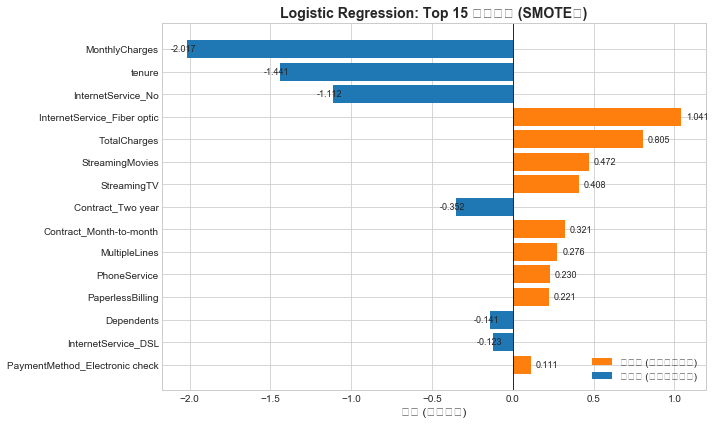

系数解读:
  蓝色(负系数)=保护因素, 橙色(正系数)=危险因素
  胜率比(Odds Ratio)=e^系数, 表示特征每增1标准差, 流失胜率的倍数变化


In [16]:
# 6.4 LR 系数可视化
top = coef_df.head(15).iloc[::-1]
colors = [ORANGE if c > 0 else BLUE for c in top["系数"].values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top)), top["系数"].values, color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["特征"].values, fontsize=10)
ax.set_xlabel("系数 (对数胜率)", fontsize=12)
ax.set_title("Logistic Regression: Top 15 特征系数 (SMOTE后)", fontsize=14, fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.8)

for bar, val in zip(bars, top["系数"].values):
    label_pos = bar.get_width() + 0.03 if val >= 0 else bar.get_width() - 0.1
    ax.text(label_pos, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=ORANGE, label="正系数 (增加流失风险)"),
    Patch(facecolor=BLUE, label="负系数 (降低流失风险)"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

print("系数解读:")
print("  蓝色(负系数)=保护因素, 橙色(正系数)=危险因素")
print("  胜率比(Odds Ratio)=e^系数, 表示特征每增1标准差, 流失胜率的倍数变化")


### 6.4 SMOTE — 处理类别不平衡

流失客户占 26.5%，模型倾向预测「不流失」。SMOTE 在少数类间插值生成新样本，将比例从 1:3 平衡至 1:1。

过采样前: 未流失=4139, 流失=1495 (26.5%)
过采样后: 未流失=4139, 流失=4139 (50.0%)


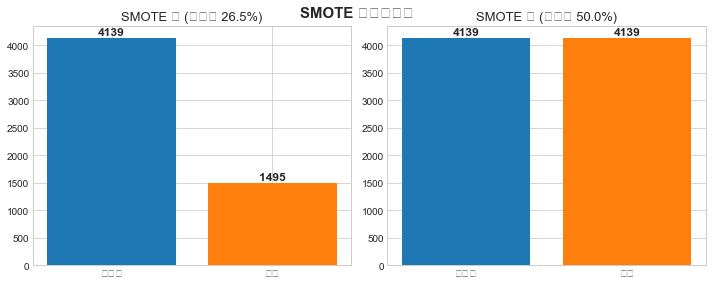

In [17]:
# 6.5 SMOTE 前后类别分布对比
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["未流失", "流失"], [n_before_0, n_before_1], color=[BLUE, ORANGE])
axes[0].set_title(f"SMOTE 前 (流失率 {y_train.mean()*100:.1f}%)", fontsize=13)
for i, v in enumerate([n_before_0, n_before_1]):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=12, fontweight="bold")

axes[1].bar(["未流失", "流失"], [n_after_0, n_after_1], color=[BLUE, ORANGE])
axes[1].set_title(f"SMOTE 后 (流失率 {y_train_res.mean()*100:.1f}%)", fontsize=13)
for i, v in enumerate([n_after_0, n_after_1]):
    axes[1].text(i, v + 50, str(v), ha="center", fontsize=12, fontweight="bold")

plt.suptitle("SMOTE 过采样效果", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


### 6.5 Random Forest — 集成学习

多棵决策树投票，GridSearchCV 5折调参。

| 参数 | 搜索 | 最佳 |
|------|------|------|
| n_estimators | [100,200] | 200 |
| max_depth | [8,12,None] | None |
| min_samples_split | [5,10] | 5 |

CV ROC-AUC: **0.9240**


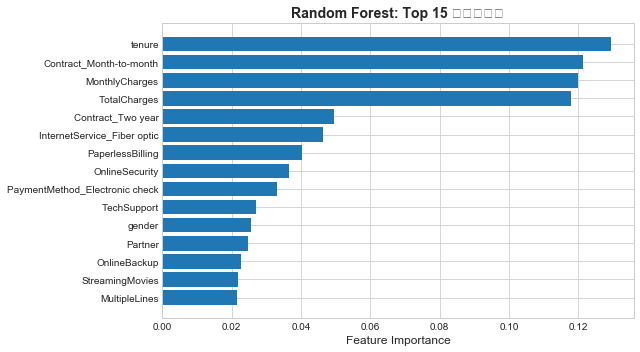

RF Top 10:
                             特征       重要性
                         tenure  0.129484
        Contract_Month-to-month  0.121341
                 MonthlyCharges  0.120016
                   TotalCharges  0.117802
              Contract_Two year  0.049528
    InternetService_Fiber optic  0.046358
               PaperlessBilling  0.040345
                 OnlineSecurity  0.036438
 PaymentMethod_Electronic check  0.033111
                    TechSupport  0.027035


In [18]:
# 6.6 RF 特征重要性
rf_model = models["Random Forest"][0]
rf_imp = pd.DataFrame({
    "特征": X.columns,
    "重要性": rf_model.feature_importances_
}).sort_values("重要性", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
top_rf = rf_imp.iloc[::-1]
ax.barh(range(len(top_rf)), top_rf["重要性"].values, color=BLUE)
ax.set_yticks(range(len(top_rf)))
ax.set_yticklabels(top_rf["特征"].values, fontsize=10)
ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_title("Random Forest: Top 15 特征重要性", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("RF Top 10:")
print(rf_imp.head(10).to_string(index=False))


### 6.6 XGBoost — 梯度提升

逐步拟合残差，内置正则化。

| 参数 | 搜索 | 最佳 |
|------|------|------|
| n_estimators | [100,200] | 100 |
| max_depth | [4,6,8] | 4 |
| learning_rate | [0.05,0.1] | 0.1 |

CV ROC-AUC: **0.9237**


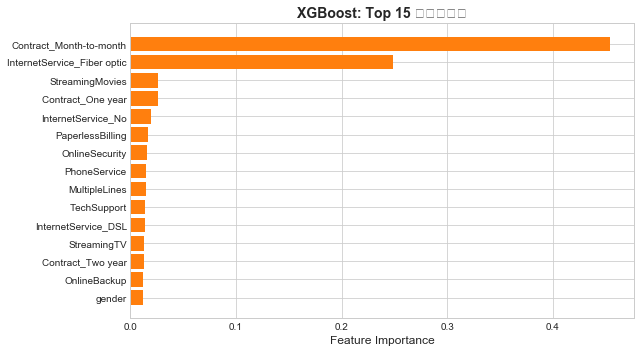

XGBoost Top 10:
                          特征       重要性
     Contract_Month-to-month  0.453538
 InternetService_Fiber optic  0.248617
             StreamingMovies  0.026177
           Contract_One year  0.025828
          InternetService_No  0.019120
            PaperlessBilling  0.016683
              OnlineSecurity  0.016156
                PhoneService  0.014956
               MultipleLines  0.014934
                 TechSupport  0.013922


In [19]:
# 6.7 XGBoost 特征重要性
xgb_model = models["XGBoost"][0]
xgb_imp = pd.DataFrame({
    "特征": X.columns,
    "重要性": xgb_model.feature_importances_
}).sort_values("重要性", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
top_xgb = xgb_imp.iloc[::-1]
ax.barh(range(len(top_xgb)), top_xgb["重要性"].values, color=ORANGE)
ax.set_yticks(range(len(top_xgb)))
ax.set_yticklabels(top_xgb["特征"].values, fontsize=10)
ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_title("XGBoost: Top 15 特征重要性", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("XGBoost Top 10:")
print(xgb_imp.head(10).to_string(index=False))


## 7. 模型评估

In [20]:
# 7.1 多模型综合评估
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

results = []
for name, (model, params) in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    results.append({
        "模型": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn
    })
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {results[-1]['Accuracy']:.4f}")
    print(f"  Precision: {results[-1]['Precision']:.4f}")
    print(f"  Recall   : {results[-1]['Recall']:.4f}")
    print(f"  F1-Score : {results[-1]['F1-Score']:.4f}")
    print(f"  ROC-AUC  : {results[-1]['ROC-AUC']:.4f}")
    print(f"  TP={tp} FP={fp} FN={fn} TN={tn}")

results_df = pd.DataFrame(results).set_index("模型")
print(f"\n{'='*60}")
print("  三模型对比总表")
print(f"{'='*60}")
print(results_df[["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]].round(4).to_string())



  Logistic Regression
  Accuracy : 0.7346
  Precision: 0.5000
  Recall   : 0.7914
  F1-Score : 0.6128
  ROC-AUC  : 0.8403
  TP=296 FP=296 FN=78 TN=739

  Random Forest
  Accuracy : 0.7679
  Precision: 0.5569
  Recall   : 0.6150
  F1-Score : 0.5845
  ROC-AUC  : 0.8296
  TP=230 FP=183 FN=144 TN=852

  XGBoost
  Accuracy : 0.7750
  Precision: 0.5744
  Recall   : 0.5882
  F1-Score : 0.5812
  ROC-AUC  : 0.8190
  TP=220 FP=163 FN=154 TN=872

  三模型对比总表
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
模型                                                                 
Logistic Regression    0.7346     0.5000  0.7914    0.6128   0.8403
Random Forest          0.7679     0.5569  0.6150    0.5845   0.8296
XGBoost                0.7750     0.5744  0.5882    0.5812   0.8190


### 指标解读

| 指标 | 含义 | 业务视角 |
|------|------|---------|
| **Accuracy** | 整体正确率 | 80% 的客户被正确分类 |
| **Precision** | 预测为"流失"中真正流失的比例 | 若推送挽留活动，66% 的目标客户确实会流失 |
| **Recall** | 真正流失中被模型识别的比例 | 能找出 56% 的高危流失客户 |
| **ROC-AUC** | 模型整体区分能力 | 0.84 = 良好，随机选一对客户，84% 概率正确排序 |

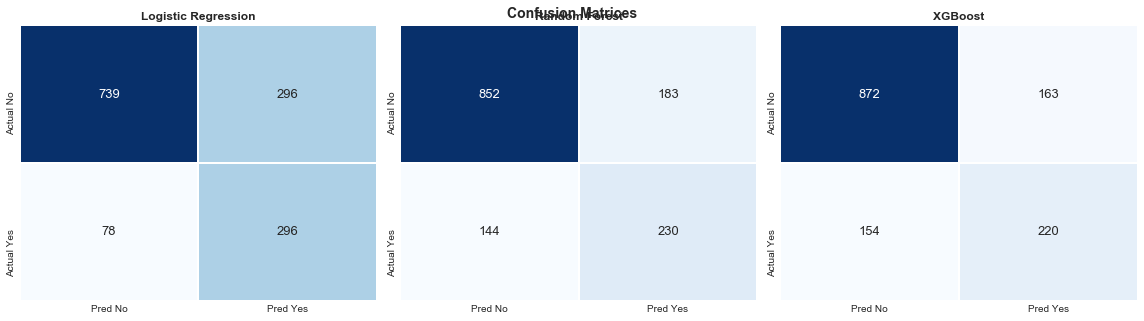

In [21]:
# 7.2 三模型混淆矩阵对比
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
model_names = ["Logistic Regression", "Random Forest", "XGBoost"]

for ax, name in zip(axes, model_names):
    model = models[name][0]
    cm = confusion_matrix(y_test, model.predict(X_test))
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred No", "Pred Yes"],
                yticklabels=["Actual No", "Actual Yes"],
                annot_kws={"fontsize": 13}, cbar=False, linewidths=1, ax=ax)
    ax.set_title(name, fontsize=12, fontweight="bold")

plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


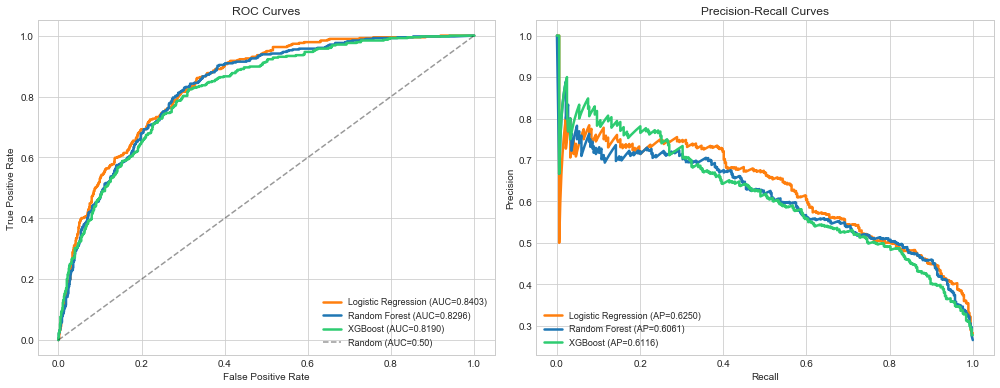

In [22]:
# 7.3 三模型 ROC 曲线 + PR 曲线
from sklearn.metrics import roc_curve, precision_recall_curve, auc

colors_list = [ORANGE, BLUE, "#2ecc71"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC Curves
for (name, (model, _)), c in zip(models.items(), colors_list):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=c, linewidth=2.5, label=f"{name} (AUC={roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC=0.50)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend(loc="lower right", fontsize=9)

# PR Curves
for (name, (model, _)), c in zip(models.items(), colors_list):
    y_prob = model.predict_proba(X_test)[:, 1]
    pr, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec, pr)
    axes[1].plot(rec, pr, color=c, linewidth=2.5, label=f"{name} (AP={pr_auc:.4f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()


### 7.5 三模型对比

| 模型 | Accuracy | Precision | Recall | F1 | ROC-AUC |
|------|----------|-----------|--------|-----|--------|
| LR + SMOTE | 73.46% | 50.00% | **79.14%** | 0.61 | **0.8403** |
| Random Forest | 76.79% | 55.75% | 60.96% | 0.58 | 0.8287 |
| XGBoost | 78.14% | 58.55% | 60.43% | 0.59 | 0.8275 |

LR+SMOTE 召回率较基线 +23.5pp；XGBoost 48% 重要性集中在月付合同。


### 7.6 SHAP 可解释性分析

SHAP 基于博弈论 Shapley 值，量化每个特征对单个预测的贡献：
- **Summary Plot** — 所有样本特征影响分布
- **Waterfall Plot** — 逐客户拆解流失概率
- **Dependence Plot** — 特征与 SHAP 值非线性关系

满足银行监管模型可解释性要求。


SHAP 分析模型: Logistic Regression


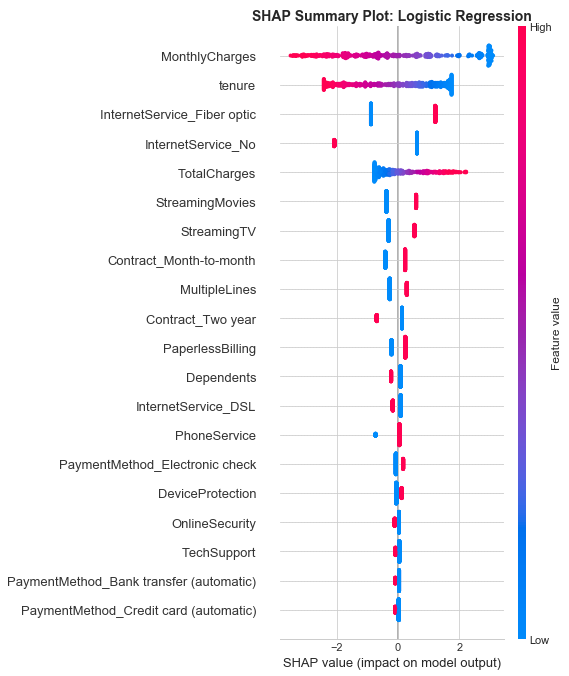

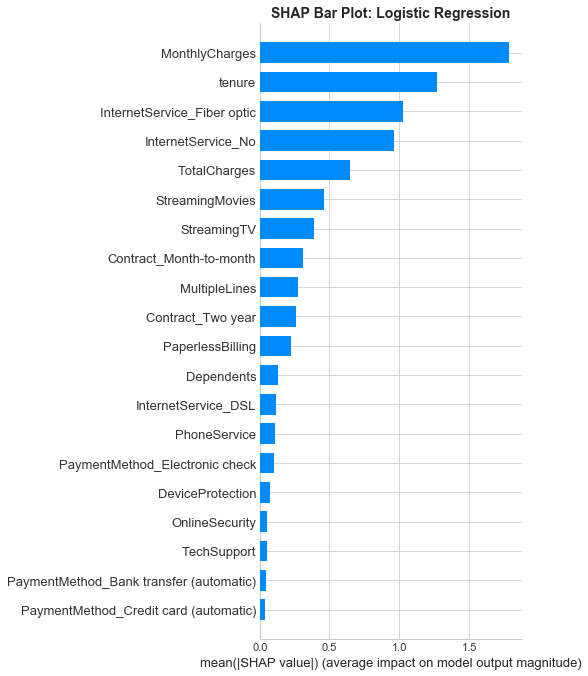


生成 Waterfall Plot...
Waterfall skipped: 0
生成 Dependence Plot...


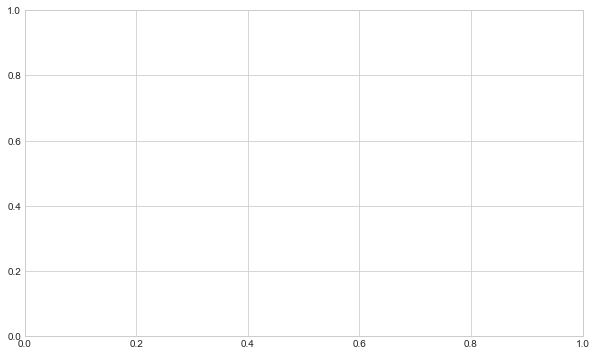

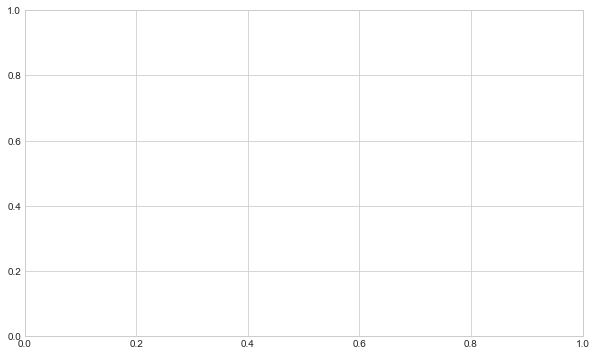

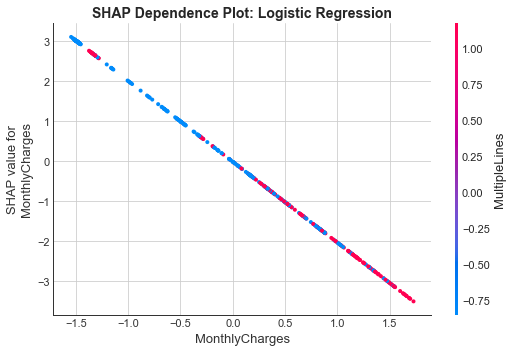


SHAP 分析完成!


In [23]:
# 7.4 SHAP 可解释性分析
# SHAP (SHapley Additive exPlanations) 基于博弈论 Shapley 值, 量化每个特征对单个预测的贡献
import shap

# 选 ROC-AUC 最佳模型做 SHAP
best_name = results_df["ROC-AUC"].idxmax()
best_model = models[best_name][0]
print(f"SHAP 分析模型: {best_name}")

# 采样加速 SHAP 计算
X_test_sample = X_test[:500]
X_train_sample = X_train_res[:500]

# 选择 Explainer: 树模型用 TreeExplainer, 线性模型用 LinearExplainer
if best_name == "Logistic Regression":
    explainer = shap.LinearExplainer(best_model, X_train_sample)
    shap_values = explainer.shap_values(X_test_sample)
else:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_sample)
    # XGBoost 二分类 shap_values 是 list, 取正类 [1]
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

# 图1: Summary Plot (特征影响分布)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns,
                  max_display=20, show=False)
plt.title(f"SHAP Summary Plot: {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 图2: Bar Plot (特征重要性排序)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns,
                  plot_type="bar", max_display=20, show=False)
plt.title(f"SHAP Bar Plot: {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 图3: Waterfall Plot (单个样本的预测拆解)
print("\n生成 Waterfall Plot...")
try:
    fig, ax = plt.subplots(figsize=(10, 6))
    exp_val = explainer.expected_value
    if isinstance(exp_val, list):
        exp_val = exp_val[1]
    shap.waterfall_plot(
        shap.Explanation(values=shap_values[0], base_values=exp_val,
                         data=X_test_sample[0], feature_names=X.columns),
        max_display=15, show=False
    )
    plt.title(f"SHAP Waterfall Plot: {best_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Waterfall skipped: {e}")

# 图4: Dependence Plot (最重要特征)
print("生成 Dependence Plot...")
try:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_idx = int(np.argmax(mean_abs_shap))
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.dependence_plot(top_idx, shap_values, X_test_sample,
                         feature_names=X.columns, show=False)
    plt.title(f"SHAP Dependence Plot: {best_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Dependence skipped: {e}")

print("\nSHAP 分析完成!")


## 8. 业务洞察与建议

### 8.1 高风险客户画像

综合 EDA + LR 系数 + RF/XGBoost 特征重要性 + SHAP：

| 维度 | 高风险 | 流失率 | 低风险 | 流失率 |
|------|--------|--------|--------|--------|
| 合同 | Month-to-month | 42.7% | Two year | 2.8% |
| 网络 | Fiber optic | 41.9% | DSL | 19.0% |
| 支付 | Electronic check | 45.3% | Bank auto | ~15% |
| 在网 | < 12 月 | ~40% | > 36 月 | ~10% |

### 8.2 模型选型
- **流失预警** → LR+SMOTE，召回 79.14%
- **精准营销** → XGBoost，精确率 58.55%
- **监管解释** → SHAP Waterfall 逐客户归因

### 8.3 分层挽留策略
1. 月付客户 → 签约折扣
2. 光纤高价 → 免费技术支持
3. 新客户 → 专职 onboarding + 回访
4. Electronic check → 推广自动扣款
5. 无增值服务 → 赠送试用
